# Cell 1 — Setup and connection

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
import os
from dotenv import load_dotenv

load_dotenv()

matplotlib.rcParams['figure.facecolor'] = '#0f1117'
matplotlib.rcParams['axes.facecolor']   = '#1a1d2e'
matplotlib.rcParams['text.color']       = '#e2e8f0'
matplotlib.rcParams['axes.labelcolor']  = '#94a3b8'
matplotlib.rcParams['xtick.color']      = '#94a3b8'
matplotlib.rcParams['ytick.color']      = '#94a3b8'
matplotlib.rcParams['axes.spines.top']  = False
matplotlib.rcParams['axes.spines.right']= False

connection_url = URL.create(
    drivername="mysql+pymysql",
    username="root",
    password=os.getenv("MYSQL_PASSWORD"),
    host="127.0.0.1",
    port=3306,
    database="ipl_db"
)

engine = create_engine(connection_url)
print("Connected to MySQL!")

Connected to MySQL!


# Cell 2 — Top 10 run scorers

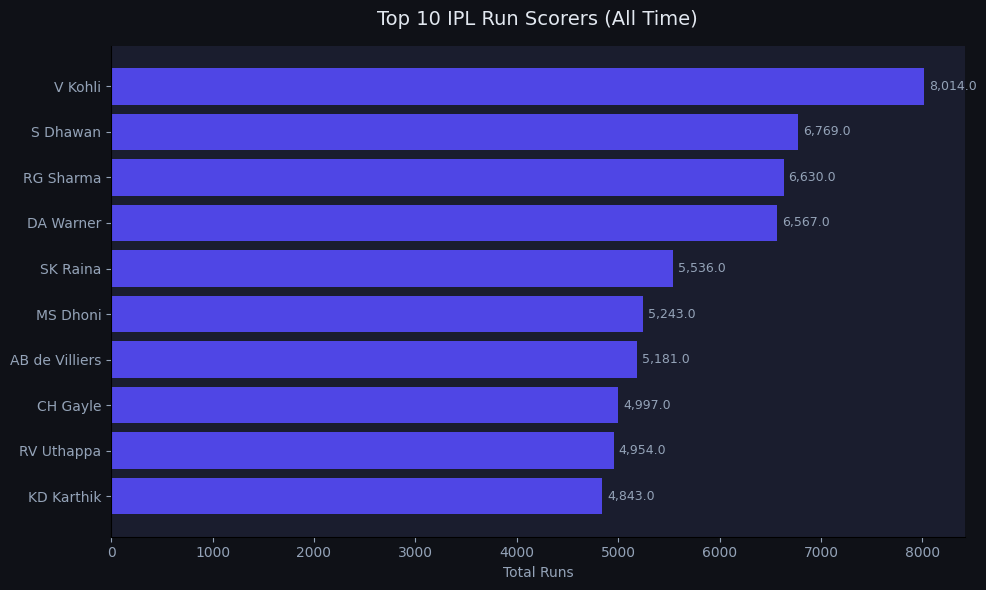

In [7]:
query = """
SELECT batter, SUM(batsman_runs) AS total_runs
FROM deliveries
GROUP BY batter
ORDER BY total_runs DESC
LIMIT 10
"""
df_runs = pd.read_sql(query, engine)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_runs['batter'], df_runs['total_runs'], color='#4f46e5')
ax.invert_yaxis()
ax.set_title('Top 10 IPL Run Scorers (All Time)', fontsize=14, pad=15, color='#e2e8f0')
ax.set_xlabel('Total Runs')
for bar, val in zip(bars, df_runs['total_runs']):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9, color='#94a3b8')
plt.tight_layout()
os.makedirs('04_python_analysis', exist_ok=True)
plt.savefig('04_python_analysis/chart_top_scorers.png', dpi=150, bbox_inches='tight')
plt.show()

# Cell 3 — Top 10 wicket takers

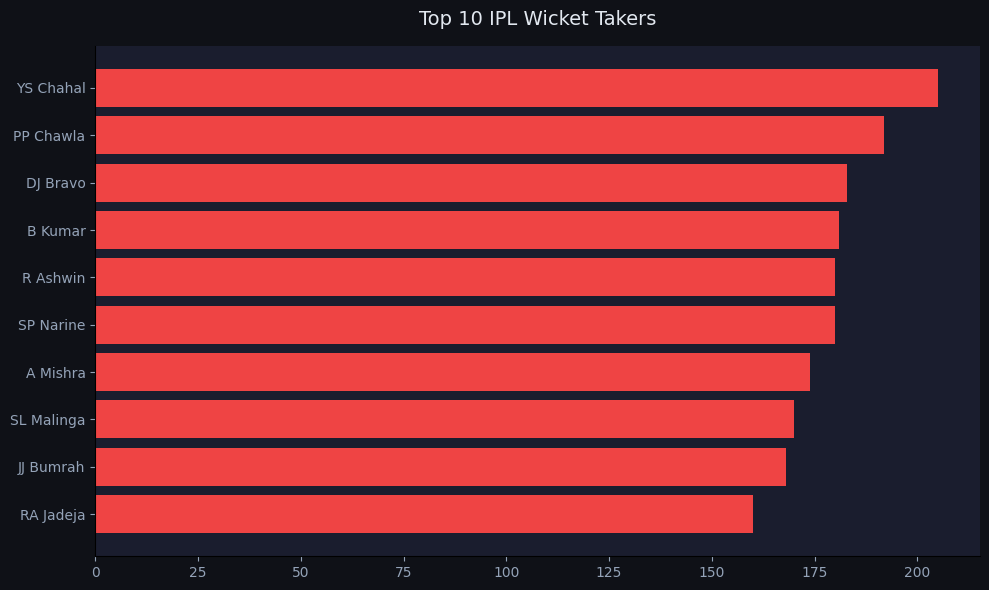

In [8]:
query = """
SELECT bowler, COUNT(*) AS wickets
FROM deliveries
WHERE dismissal_kind IS NOT NULL
AND dismissal_kind NOT IN ('run out','retired hurt','obstructing the field')
GROUP BY bowler ORDER BY wickets DESC LIMIT 10
"""
df_wkts = pd.read_sql(query, engine)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_wkts['bowler'], df_wkts['wickets'], color='#ef4444')
ax.invert_yaxis()
ax.set_title('Top 10 IPL Wicket Takers', fontsize=14, pad=15, color='#e2e8f0')
plt.tight_layout()
plt.savefig('04_python_analysis/chart_top_wickets.png', dpi=150, bbox_inches='tight')
plt.show()

# Cell 4 — Season-wise total runs trend

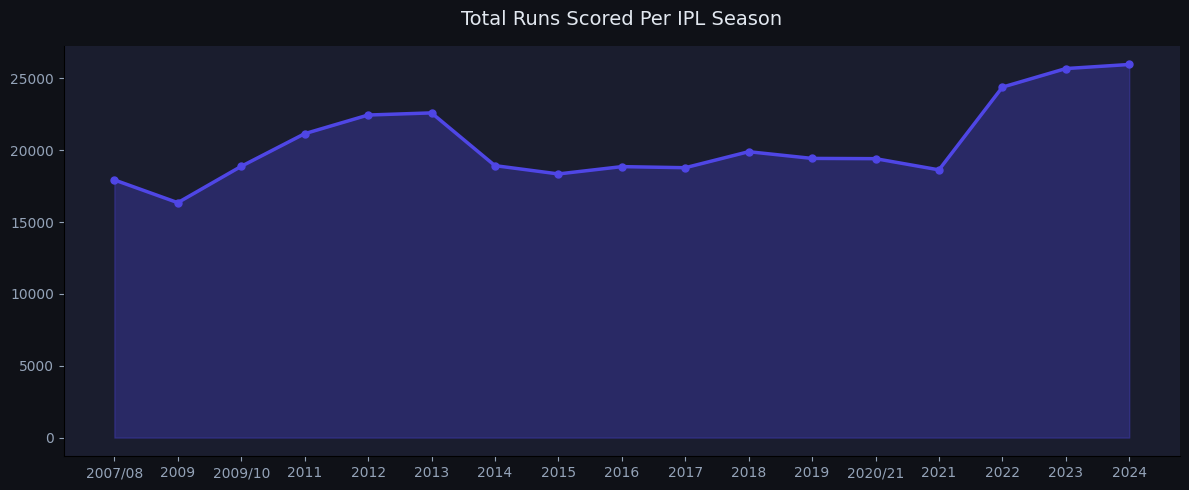

In [9]:
query = """
SELECT m.season, SUM(d.total_runs) AS total_runs
FROM deliveries d
JOIN matches m ON d.match_id = m.id
GROUP BY m.season ORDER BY m.season
"""
df_season = pd.read_sql(query, engine)

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(df_season['season'], df_season['total_runs'],
                alpha=0.3, color='#4f46e5')
ax.plot(df_season['season'], df_season['total_runs'],
        color='#4f46e5', linewidth=2.5, marker='o', markersize=5)
ax.set_title('Total Runs Scored Per IPL Season', fontsize=14, pad=15, color='#e2e8f0')
plt.tight_layout()
plt.savefig('04_python_analysis/chart_season_runs.png', dpi=150, bbox_inches='tight')
plt.show()

# Cell 5 — Toss decision win % (pie chart)

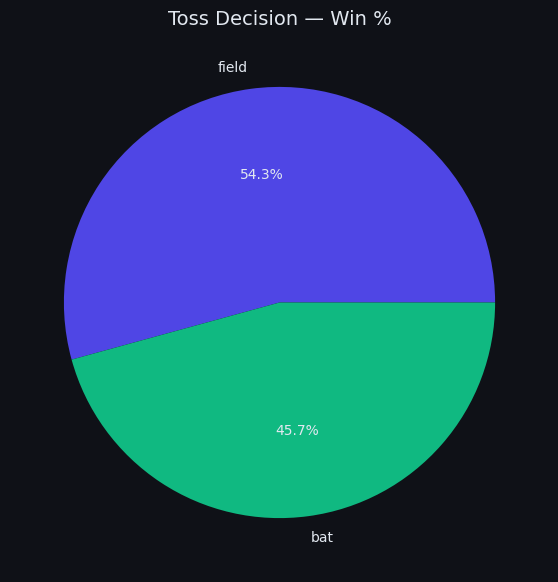

In [10]:
query = """
SELECT toss_decision,
COUNT(*) AS total,
SUM(CASE WHEN toss_winner = winner THEN 1 ELSE 0 END) AS won
FROM matches WHERE winner IS NOT NULL
GROUP BY toss_decision
"""
df_toss = pd.read_sql(query, engine)
df_toss['win_pct'] = df_toss['won'] / df_toss['total'] * 100

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(df_toss['win_pct'], labels=df_toss['toss_decision'],
       autopct='%1.1f%%', colors=['#4f46e5', '#10b981'],
       textprops={'color':'#e2e8f0'})
ax.set_title('Toss Decision — Win %', fontsize=14, color='#e2e8f0')
plt.savefig('04_python_analysis/chart_toss.png', dpi=150, bbox_inches='tight')
plt.show()

# Cell 6 — Most sixes

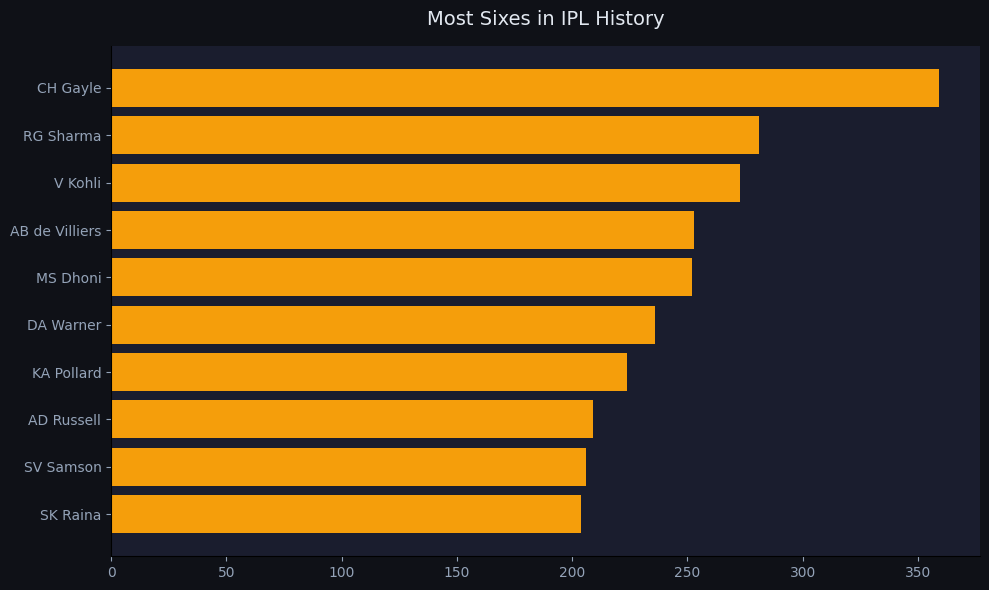

In [11]:
query = """
SELECT batter, COUNT(*) AS sixes
FROM deliveries WHERE batsman_runs = 6
GROUP BY batter ORDER BY sixes DESC LIMIT 10
"""
df_sixes = pd.read_sql(query, engine)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_sixes['batter'], df_sixes['sixes'], color='#f59e0b')
ax.invert_yaxis()
ax.set_title('Most Sixes in IPL History', fontsize=14, pad=15, color='#e2e8f0')
plt.tight_layout()
plt.savefig('04_python_analysis/chart_sixes.png', dpi=150, bbox_inches='tight')
plt.show()

# Cell 7 — Best economy bowlers

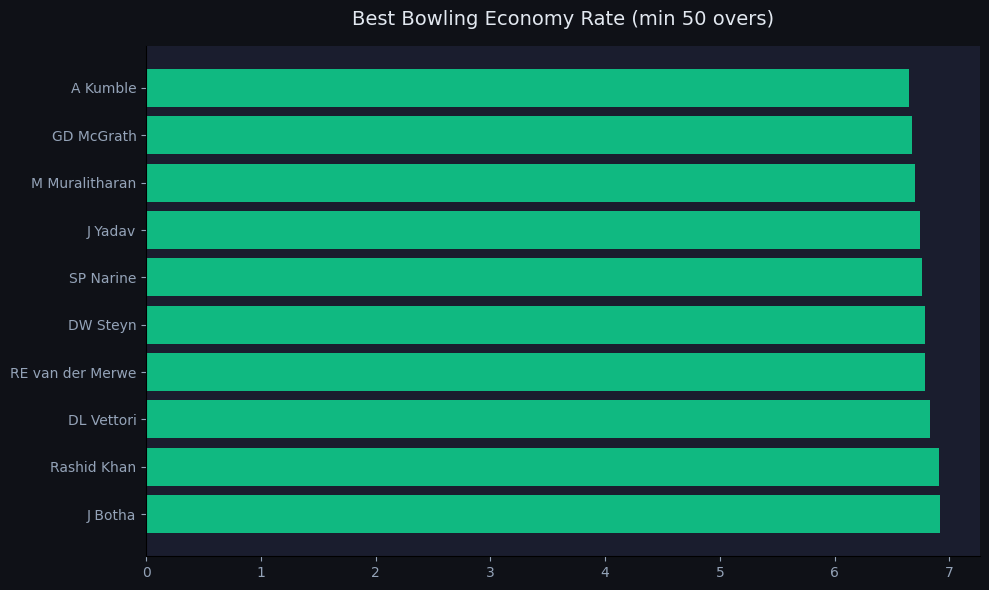

In [12]:
query = """
SELECT bowler,
ROUND(SUM(total_runs) * 6.0 / COUNT(*), 2) AS economy
FROM deliveries
GROUP BY bowler HAVING COUNT(*) >= 300
ORDER BY economy ASC LIMIT 10
"""
df_eco = pd.read_sql(query, engine)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_eco['bowler'], df_eco['economy'], color='#10b981')
ax.invert_yaxis()
ax.set_title('Best Bowling Economy Rate (min 50 overs)', fontsize=14, pad=15, color='#e2e8f0')
plt.tight_layout()
plt.savefig('04_python_analysis/chart_economy.png', dpi=150, bbox_inches='tight')
plt.show()

# Cell 8 — Top venues by avg score

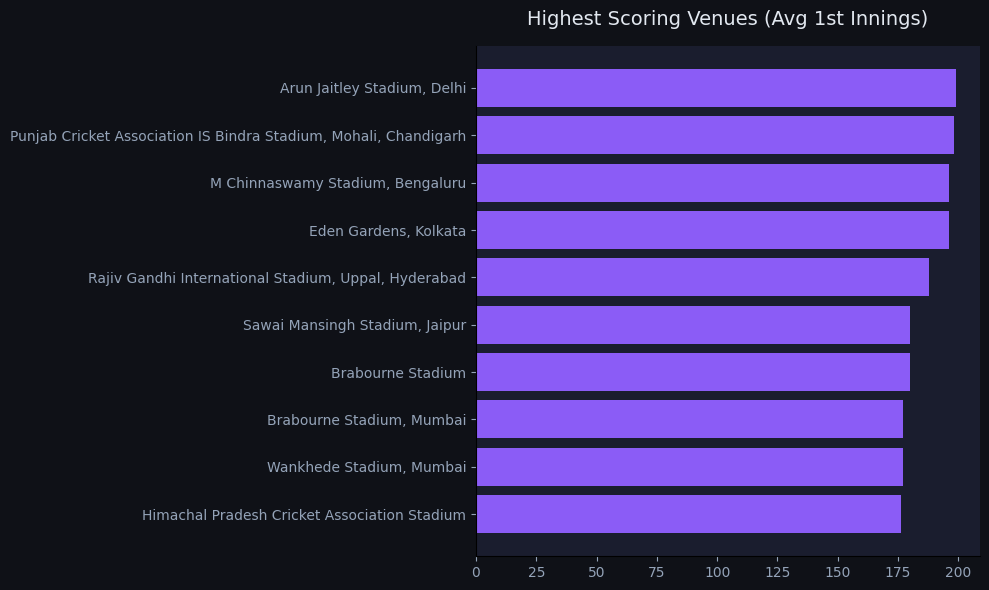

In [13]:
query = """
SELECT m.venue,
ROUND(AVG(inn.innings_total), 0) AS avg_score,
COUNT(*) AS matches
FROM matches m
JOIN (
    SELECT match_id, SUM(total_runs) AS innings_total
    FROM deliveries WHERE inning = 1
    GROUP BY match_id
) inn ON m.id = inn.match_id
GROUP BY m.venue HAVING COUNT(*) >= 5
ORDER BY avg_score DESC LIMIT 10
"""
df_venues = pd.read_sql(query, engine)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_venues['venue'], df_venues['avg_score'], color='#8b5cf6')
ax.invert_yaxis()
ax.set_title('Highest Scoring Venues (Avg 1st Innings)', fontsize=14, pad=15, color='#e2e8f0')
plt.tight_layout()
plt.savefig('04_python_analysis/chart_venues.png', dpi=150, bbox_inches='tight')
plt.show()